    学号：22344112

    姓名：潘嘉锐


（13分）1、在拒绝采样中，用高斯分布作为提议分布，要求重构出目标概率密度函数，并画图比较。目标概率密度为： $x^2\exp(-0.5 x^2)$

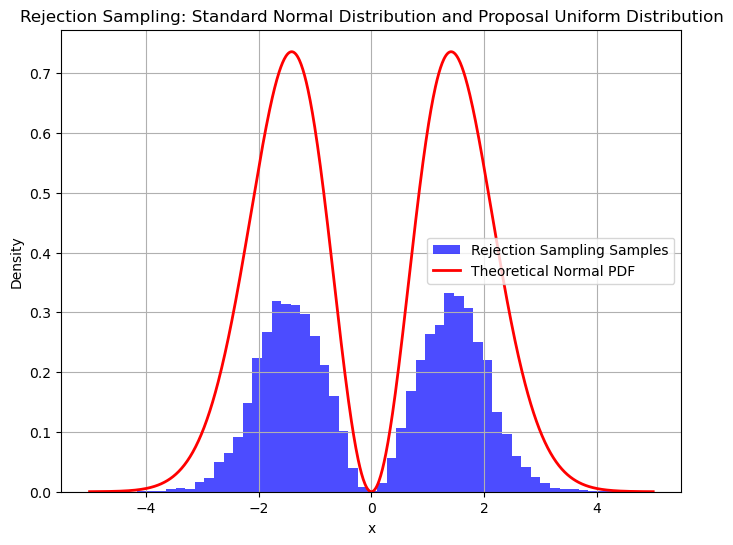

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def target_pdf(x):
    return x**2*np.exp(-0.5 * x**2) 

def proposal_pdf(x):
    return np.exp(-0.5 * x**2)/ np.sqrt(2 * np.pi)

# 实现拒绝采样算法
def rejection_sampling(target_pdf, proposal_pdf, M, n_samples):
    """
    拒绝采样主函数
    Parameters:
        target_pdf (function): 目标分布的PDF函数
        proposal_pdf (function): 提议分布的PDF函数
        M (float): 缩放因子，需满足 target_pdf(x) <= M*proposal_pdf(x) 对所有x成立
        b (float): 均匀分布的半区间范围
        n_samples (int): 需要生成的样本数量
    Returns:
        array: 生成的样本数组
    """
    samples = []
    while len(samples) < n_samples:
        # Step 1: 从提议分布g(x)中生成候选样本（此处为均匀分布）
        x_star = np.random.normal(0,1)  # 在[-b, b]范围内均匀采样
        
        # Step 2: 生成一个均匀分布的随机数 $u \in [0, 1]$，然后计算
        u = np.random.rand()
        
        # Step 3: 接受-拒绝条件判断
        # 计算 M*g(x_star)*u 并与目标分布f(x_star)比较
        # 公式：若 u <= f(x_star)/(M*g(x_star)) 则接受样本
        if u * M * proposal_pdf(x_star) <= target_pdf(x_star):
            samples.append(x_star)
    return np.array(samples)

# 参数设置
M =10  # 确保M满足f(x) <= M * g(x)
n_samples = 10000   # 生成的样本数

# 进行拒绝采样
samples = rejection_sampling(target_pdf, proposal_pdf, M, n_samples)

# 绘制生成的样本的直方图
plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='blue', label='Rejection Sampling Samples')

x = np.linspace(-5, 5, 1000)
pdf = target_pdf(x)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Normal PDF')

proposal_x = np.linspace(-3, 3, 1000)
proposal_pdf_vals = []
for xi in proposal_x:
    proposal_pdf_vals.append(M*proposal_pdf(xi))

#plt.plot(proposal_x, proposal_pdf_vals, 'g--', lw=2, label='Proposal Uniform PDF')

# 设置图形
plt.title('Rejection Sampling: Standard Normal Distribution and Proposal Uniform Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

(13分)2、用metropolis_hastings算法，生成一个双峰分布的样本（目标分布如下），并画图比较生成的样本和目标分布。
target_pdf(x): 0.5 * np.exp(-0.5 * ((x + 3) ** 2)) / np.sqrt(2 * np.pi) + 0.5 * np.exp(-0.5 * ((x - 3) ** 2)) / np.sqrt(2 * np.pi)

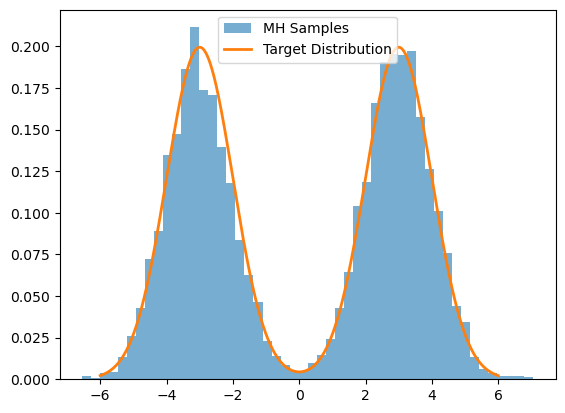

In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.special import gamma

def metropolis_hastings(target_pdf, proposal_sampler, num_samples=10000, init_x=0):
    samples = []
    x_t = init_x
    
    for _ in range(num_samples):
        x_star = proposal_sampler(x_t)  # 生成候选样本
        A = min(1, target_pdf(x_star) / target_pdf(x_t))  # 计算接受率
        
        if np.random.rand() < A:
            x_t = x_star  # 接受候选样本
        
        samples.append(x_t)
    
    return np.array(samples)

# 目标分布
def target_pdf(x):
    return  0.5 * np.exp(-0.5 * ((x + 3) ** 2)) / np.sqrt(2 * np.pi) + 0.5 * np.exp(-0.5 * ((x - 3) ** 2)) / np.sqrt(2 * np.pi)

# 高斯建议分布：N(x_t, 1)
sigma=1
def proposal_sampler(x):
    return x + np.random.normal(0, sigma) # sigma合适选取，增加接受率

# 运行 MH 采样
samples = metropolis_hastings(target_pdf, proposal_sampler)

# 绘制直方图
plt.hist(samples, bins=50, density=True, alpha=0.6, label="MH Samples")
x = np.linspace(-6, 6, 1000)
plt.plot(x, target_pdf(x), label="Target Distribution", linewidth=2)
plt.legend()
plt.show()

（7分）3、已知信号为 $f(t) = [\cos(2\pi t)]^{10}$，假设采样率为 1000 Hz，采样时间为 1 秒，生成信号的离散时间序列。使用快速傅里叶变换（FFT）将其变换到频域，然后设计一个带通滤波器，仅保留 10 Hz ± 0.5 Hz 的频率成分，并将其余频率置零。然后对滤波后的频谱进行傅里叶逆变换（IFFT）恢复时域信号，并将原始信号与滤波后的信号进行可视化对比（ $t\in[0,1]$秒），观察是否成功提取出 10 Hz 成分。

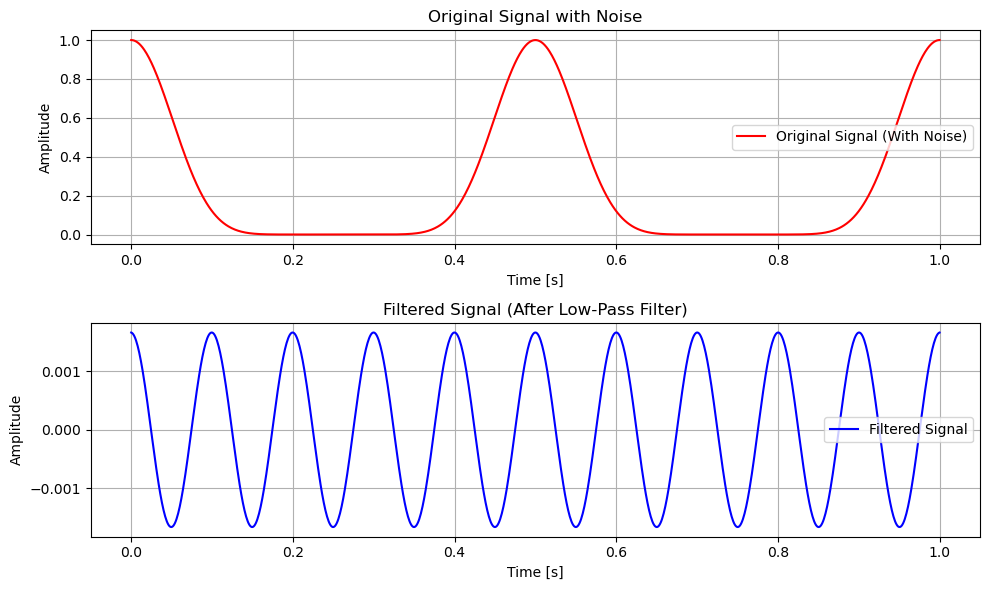

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#  设置时间和频率
t=np.linspace(0,1,1000)

# 生成正弦波信号
signal = np.cos(2*np.pi*t)**10

# 傅里叶变换
signal_freq = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(t), t[1] - t[0])

filter_mask1 = np.abs(frequencies)<=10.5
filter_mask2 = np.abs(frequencies)>=9.5
signal_freq_filtered = signal_freq * filter_mask1*filter_mask2  # 应用滤波器

# 傅里叶逆变换得到去噪信号
signal_filtered = np.fft.ifft(signal_freq_filtered)

# 绘制结果
plt.figure(figsize=(10, 6))

# 绘制原始信号
plt.subplot(2, 1, 1)
plt.plot(t, signal, label="Original Signal (With Noise)", color='r')
plt.title("Original Signal with Noise")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# 绘制去噪后的信号（只取实部）
plt.subplot(2, 1, 2)
plt.plot(t, np.real(signal_filtered), label="Filtered Signal", color='b')
plt.title("Filtered Signal (After Low-Pass Filter)")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

（17分）4、已知下列常微分方程和初始条件：

$\frac{dy}{dt} + 2y = e^{-t}, \quad y(0) = 1 $

补充下面代码，完成以下题目要求：
1. 写出计算该微分方程dy/dt的函数`dydt(y, t)` (3分)
2. 完成四阶龙格-库塔（RK4）方法函数`odeint_rk4(f, r0, t)`, 其中`f`为常微分方程，`r0`为初始条件，`t`为求解时间数组 (5分）
3. 带入初始条件`y0 = 1`, 使用`odeint_rk4`计算 t 在`0-1`区间，等间隔取`100`个点的方程解y，并绘制y随时间变化的曲线图。(4分）
4. 已知该函数的解析解为$y = e^{-t}$，通过改变步长 $h$ ($h=0.1,\,0.01,\,0.001$)，分别计算t=1时刻的数值解，绘制累积近似误差与步长的关系图，应表现为4阶精度。（5分）

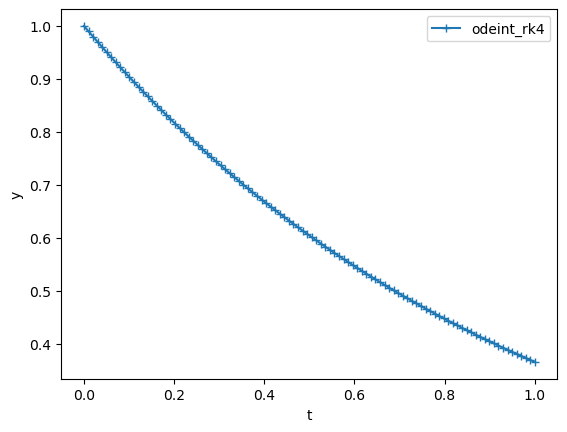

In [43]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# 1. 写出计算该微分方程dy/dt的函数
def dydt(y, t):
    v=y#定义导函数
    f = np.exp(-t)  
    dvdt = f-2*v
    return dvdt
    

# 2. RK4 常微分求解函数
def odeint_rk4(f, y0, t):
    ylist = [y0]
    y = y0
    t0 = t[0]  
    for t1 in t[1:]:
        dt = t1-t0
        h=dt
        ylast=ylist[-1]
        k1 = f(ylast, t1)  # 初始点斜率
        k2 = f(ylast + h*k1/2, t1 + h/2)  # 中间点斜率1
        k3 = f(ylast + h*k2/2, t1 + h/2)  # 中间点斜率2
        k4 = f(ylast + h*k3, t1 + h)  # 终点斜率
        
        # 计算下一步的状态值（加权平均斜率）
        y = y + h/6*(k1 + 2*k2 + 2*k3 + k4)
        
        ylist.append(y)  # 存储结果
        
        t0 = t1 # 更新时间


    return np.array(ylist)

# 3. 设置初始条件和积分区间，带入求解
t = np.linspace(0,1,100)
y0 = 1
y = odeint_rk4(dydt,y0,t)

# 绘制结果
fig, axes = plt.subplots(1,1)
axes.plot(t, y, '-+', label='odeint_rk4')
axes.set_xlabel('t')
axes.set_ylabel('y')
axes.legend()

Text(0, 0.5, 'error')

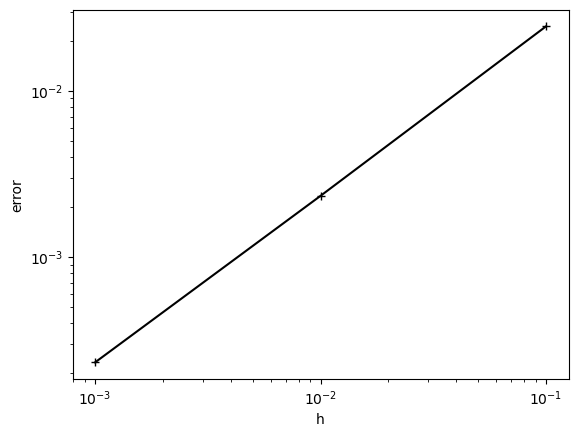

In [48]:
# 4. 累积近似误差分析
steps = [0.1, 0.01, 0.001]
error = []
for h in steps:
    # 将每个h对应的累积近似误差存入error列表
    t_arr = np.linspace(0, 1,int(1/h))
    y_arr = odeint_rk4(dydt, y0, t_arr)

    # 补全误差计算部分，得到LTE_max
    CTE= np.abs(np.exp(-1)-y_arr[-1])
    error.append(CTE)

# 绘图函数
plt.figure()
plt.plot(steps, error, '-+', color='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('h')
plt.ylabel('error')

（17分）5、光在经过介质表面会发生折射现象，对应折射定律 $n_1 \sin(\theta_1) = n_2 \sin(\theta_2)$，以下代码利用有限差分法求解二维波动方程，实现折射现象的数值模拟，并绘制场强分布图。其中:
- $u$：波动方程的待求解函数，为电场的分量，对应场强$u^2$。
- 两种介质波速设置：模拟的二维区域中存在两种不同介质，分别对应折射率$n_1$和$n_2$，以及波速$c/n_1$和$c/n_2$，其分界线由函数$y = 2(x-x_0)$描述（完成题目成功绘图后，为图中的黄色曲线表示）。由于波速不是统一常数，因此模拟中用二维数组c_map来根据每个格点所在介质来存储对应的波速。
- 有限差分格式：中心（三层）差分格式
- 边界条件：左侧边界设置为单色平行波源，向右侧发射正弦波动，其他边界为吸收边界。

请基于以下要求补充代码中缺失的部分，完成模拟，并成功绘制T=3时间单位时的光强分布图。
1. 补充中间格点的中心差分计算，实现u_new的更新（10分）。
2. 补充左边界单色平面波源的边界条件，发射正弦波动（4分）。
3. 设置迭代次数Nt，计算t=3时刻的场强分布图（3分）。


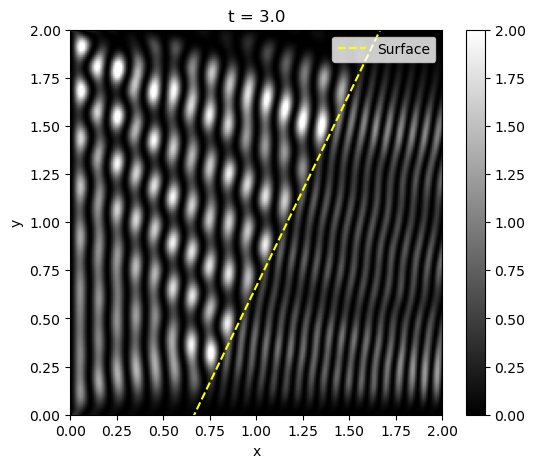

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib widget

# 空间参数
Lx, Ly = 2.0, 2.0
Nx, Ny = 200, 200
dx, dy = Lx / Nx, Ly / Ny
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# 斜界面函数 y = 2*(x-X0)
def y_boundary(x, X0):
    return 2*(x- X0)

# 介质1区域选择函数 
X0 = Lx/3   # 斜界面在y=0处的x值
def in_medium1(x, y):  # 大于斜线在介质1，否则在介质2
    return y > y_boundary(x, X0)

# 两区折射率与波速
n1 = 1.0
n2 = 1.5
c = 1.0

# 建立每个格点的波速二维数组
c_map = np.where(in_medium1(X, Y), c/n1, c/n2)

# 时间步长
dt = 0.001

# 设置迭代次数，计算t=3时刻的结果
Nt = 3000

# 波参数
wavelength = 0.2
k = 2 * np.pi / wavelength
omega = c / n1 * k  # 只用n1是因为左区发射与主要传播速度

# 初始条件
u_now = np.zeros((Nx, Ny))   # 当前步的u
u_old = np.zeros_like(u_now) # 上一步的u
u_new = np.zeros_like(u_now) # 下一步的u

# 迭代计算循环
for n in range(Nt):
    
    # 中心差分格式，中间格点更新，补充完整u_new中间格点计算：
    u_new[1:-1, 1:-1] = 2*u_now[1:-1,1:-1] - u_old[1:-1,1:-1] +\
    (c_map[1:-1,1:-1]*dt/dx)**2 * (u_now[2:,1:-1] + u_now[:-2,1:-1] + u_now[1:-1,2:] + u_now[1:-1,:-2] - 4*u_now[1:-1,1:-1])
    
    # 吸收边界
    u_new[:,0] = u_now[:,0] + c_map[:,0] *dt/dx*(u_now[:,1] - u_now[:,0])
    u_new[:,-1] = u_now[:,-1] + c_map[:,-1] *dt/dx*(u_now[:,-2] - u_now[:,-1])
    u_new[-1,:] = u_now[-1,:] + c_map[-1,:] *dt/dx*(u_now[-2,:] - u_now[-1,:])
    
    t = n * dt
    # 补充左边界平面波源代码,发射正弦平面波 sin(-omega t)
    u_new[0,:] = np.sin(-omega*t)

    # 更新u_old和u_now
    u_old = u_now.copy()
    u_now = u_new.copy()

# 绘制光强分布图
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(u_now.T**2, vmin=0, vmax=2, cmap="binary_r", origin="lower",
               extent=[0, Lx, 0, Ly], aspect='auto')

# 绘制斜界面
xx = np.linspace(0, Lx, 2)
yy = y_boundary(xx, X0)
ax.plot(xx, yy, color="yellow", ls="--", lw=1.5, label="Surface")

# 绘图参数设置
plt.colorbar(im, ax=ax)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)
ax.legend(loc='upper right')
ax.set_title(f"t = {Nt*dt}")
plt.show()

(24分) 6、分类算法的使用。

下面的X, y是手写体数据集的数据和标签。

（1）请将样本划分为训练集与测试集，比例分别为60%、40%（3分）。

（2）在测试集上评估 k-近邻、逻辑回归、svm（使用linear和rbf核函数）、决策树、随机森林、神经网络（任选架构）的表现。对每个模型，打印出模型名字和模型在测试集上的准确率（21分）。

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, metrics, model_selection, neighbors, linear_model, svm, tree, ensemble, naive_bayes, neural_network
from sklearn.svm import SVC
data = datasets.load_digits()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.6)

model_knn = neighbors.KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)
scores_knn = model_selection.cross_val_score(model_knn, X, y, cv=5)
print("knn平均准确率:", np.mean(scores_knn))

model_linear = linear_model.LogisticRegression(max_iter = 10000)
model_linear.fit(X_train, y_train)
scores_linear = model_selection.cross_val_score(model_linear, X, y, cv=5)
print("逻辑回归平均准确率:", np.mean(scores_linear))

model_SVCR = SVC(kernel='rbf', C=200).fit(X, y)
model_SVCR.fit(X_train, y_train)
scores_SVCR = model_selection.cross_val_score(model_SVCR, X, y, cv=5)
print("SVM(rbf核)平均准确率:", np.mean(scores_SVCR))

model_SVCL = SVC(kernel='linear', C=200).fit(X, y)
model_SVCL.fit(X_train, y_train)
scores_SVCL = model_selection.cross_val_score(model_SVCL, X, y, cv=5)
print("SVM(linear核)平均准确率:", np.mean(scores_SVCL))

model_tree = tree.DecisionTreeClassifier(criterion='gini') #也可以用criterion = entropy
model_tree.fit(X_train,y_train)
scores_tree = model_selection.cross_val_score(model_tree, X, y, cv=5)
print("决策树平均准确率:", np.mean(scores_tree))

#训练模型1，RandomForest（随机森林）
model_RF = ensemble.RandomForestClassifier(n_estimators=50, criterion='entropy')
model_RF.fit(X,y)
scores_RF = model_selection.cross_val_score(model_RF, X, y, cv=5)
print("随机森林平均准确率:", np.mean(scores_RF))

model_ANN = neural_network.MLPClassifier((50,20,),  )
model_ANN.fit(X,y)
scores_ANN = model_selection.cross_val_score(model_ANN, X, y, cv=5)
print("ANN平均准确率:", np.mean(scores_ANN))

knn平均准确率: 0.9627282575054161
逻辑回归平均准确率: 0.9143160012380068
SVM(rbf核)平均准确率: 0.9738502011761063
SVM(linear核)平均准确率: 0.9476973073351903
决策树平均准确率: 0.789692045806252
随机森林平均准确率: 0.9304642525533892
ANN平均准确率: 0.9276632621479418



(9分) 7、一个回归问题。

下面是一个走势奇特的数据。随着 x 增加，y 先增加、再减小、最后又突然增加。

请用 ***岭回归*** 拟合这个数据。要求***（1）使用10阶多项式；（2）取alpha=0.1***。请在(3,4)区间绘制出拟合函数的图像。

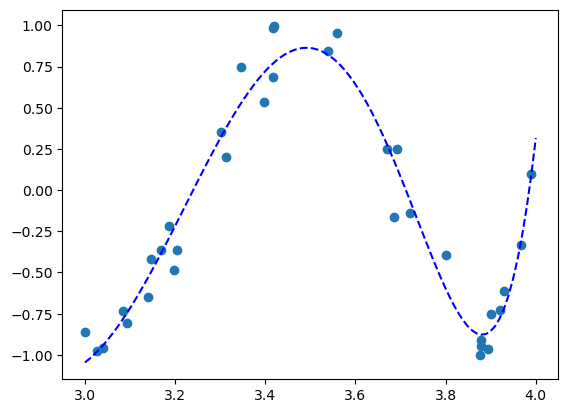

In [88]:
x = np.array([ 3.417022004702574,3.720324493442158,3.000114374817345,3.3023325726318395,3.146755890817113,3.0923385947687976,3.186260211377671,3.345560727043048,3.39676747423067,3.538816734003357,3.4191945144032947,3.6852195003967596,3.2044522497315175,3.878117436390945,3.0273875931979264,3.670467510178402,3.417304802367127,3.5586898284457518,3.140386938595234,3.1981014890848787,3.800744568675537,3.9682615757193975,3.313424178159243,3.692322615669314,3.8763891522960385,3.8946066635038474,3.085044211369778,3.0390547832328823,3.169830419564569,3.8781425034294132,3.9,3.92,3.93,3.99 ])
y = np.array([ 0.6843408665399496,-0.13755302914459389,-0.863390491459802,0.35146861985188843,-0.41864874411541886,-0.8057533783199663,-0.215526504583916,0.7479752294641533,0.5353002914342695,0.8459479083316076,0.9936073072976723,-0.16527488527685827,-0.3644367790554646,-0.9094802205127568,-0.979338916914584,0.24801201212073268,0.9822925629746214,0.9515064420581822,-0.6510630109183191,-0.48188814316754697,-0.3952020610358508,-0.3326219080914577,0.19917430804452751,0.24839130119769112,-0.9979219036607093,-0.9622844152308694,-0.7351128013209435,-0.9606224445510483,-0.360401765535194,-0.9477972051772033,-0.75,-0.73,-0.61,0.1 ])
plt.scatter(x, y)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# 手动增加高阶特征
deg = 10
X_extend = np.column_stack([x**row for row in range(1,deg+1)])
xdense = np.linspace(3,4,100)
### 使用岭回归，解决过拟合问题
model = linear_model.Ridge(alpha=1)
model.fit(X_extend, y)
y_predict = model.predict(np.column_stack([xdense**row for row in range(1,deg+1)]))
plt.plot(xdense, y_predict, c='b', ls='--', label='deg = 15, Ridge (alpha=1)')